In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# Load dataset
data = pd.read_csv("wdbc.data", header=None)

# Column names
columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data.columns = columns

# Display dataset
print(data.head())
print(data.shape)

         id diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  ...  feature_21  feature_22  feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   feature_24  feature_25  feature_26  featu

In [3]:
# Convert diagnosis into numerical values
data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

# Remove ID column
X = data.drop(columns=["id", "diagnosis"])
y = data["diagnosis"]

print("Missing values:")
print(X.isnull().sum().sum())

print("\nClass distribution:")
print(y.value_counts())

Missing values:
0

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_params = {
    "n_estimators": [10, 25, 50, 100],
    "max_samples": [0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0]
}

bagging_grid = GridSearchCV(
    bagging,
    bagging_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

print("Best Bagging Parameters:")
print(bagging_grid.best_params_)

print("Best CV Accuracy:")
print(bagging_grid.best_score_)

Best Bagging Parameters:
{'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 25}
Best CV Accuracy:
0.9714285714285715


In [9]:
bagging_f1 = GridSearchCV(
    bagging,
    bagging_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

bagging_f1.fit(X_train, y_train)

print("Best Bagging F1 Score:")
print(bagging_f1.best_score_)

Best Bagging F1 Score:
0.9621372130941929


In [11]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

adaboost_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

adaboost_grid = GridSearchCV(
    adaboost,
    adaboost_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

adaboost_grid.fit(X_train, y_train)

print("Best AdaBoost Parameters:")
print(adaboost_grid.best_params_)

print("Best AdaBoost CV Accuracy:")
print(adaboost_grid.best_score_)

Best AdaBoost Parameters:
{'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 150}
Best AdaBoost CV Accuracy:
0.9758241758241759


In [12]:
gradient = GradientBoostingClassifier(
    random_state=42
)

gradient_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 2, 3]
}

gradient_grid = GridSearchCV(
    gradient,
    gradient_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gradient_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gradient_grid.best_params_)

print("Best Gradient Boosting CV Accuracy:")
print(gradient_grid.best_score_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 150}
Best Gradient Boosting CV Accuracy:
0.9758241758241759


In [13]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True, random_state=42))
])

naive_bayes = GaussianNB()

decision_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

base_models = [
    ("svm", svm),
    ("nb", naive_bayes),
    ("dt", decision_tree)
]

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking.fit(X_train, y_train)

print("Stacking model trained successfully.")

Stacking model trained successfully.


In [14]:
models = {
    "Bagging": bagging_grid.best_estimator_,
    "AdaBoost": adaboost_grid.best_estimator_,
    "Gradient Boosting": gradient_grid.best_estimator_,
    "Stacking": stacking
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy * 100,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(results_df)

               Model  Accuracy (%)  Precision    Recall  F1 Score
0            Bagging     96.491228        1.0  0.904762  0.950000
1           AdaBoost     97.368421        1.0  0.928571  0.962963
2  Gradient Boosting     96.491228        1.0  0.904762  0.950000
3           Stacking     96.491228        1.0  0.904762  0.950000


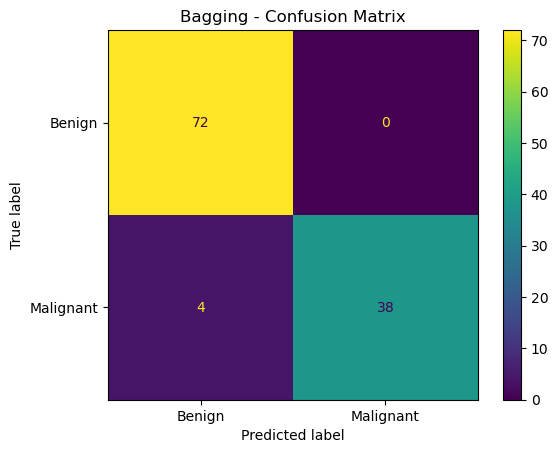

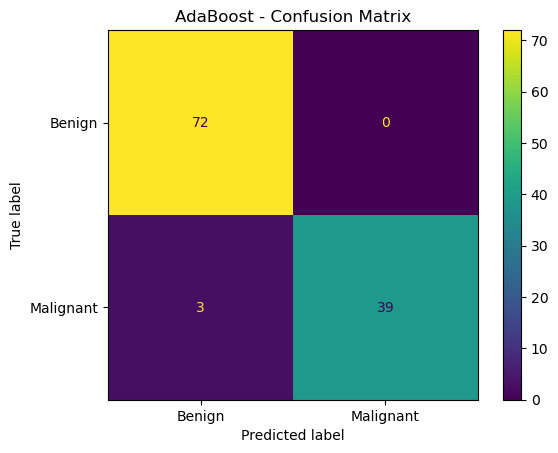

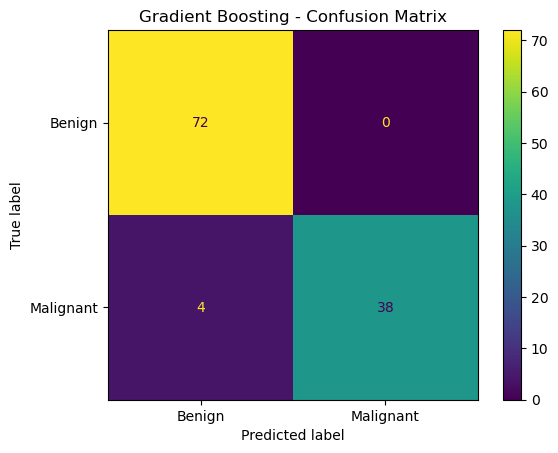

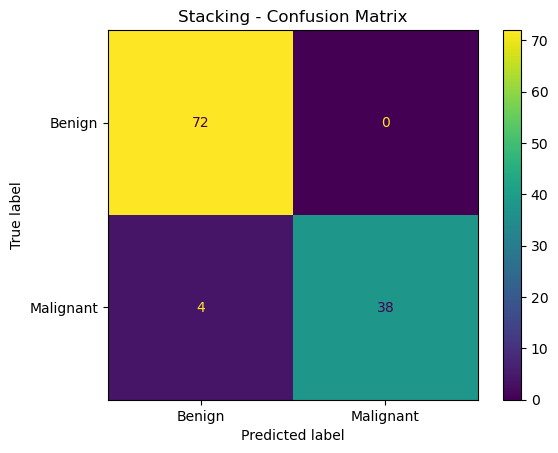

In [15]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()

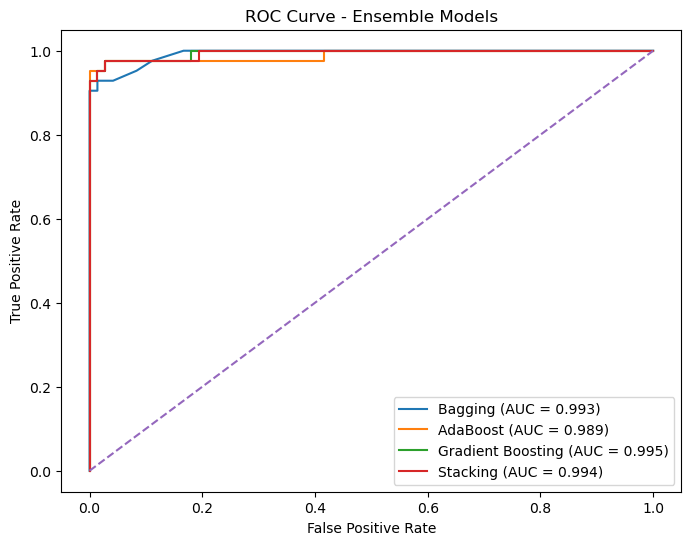

In [16]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Models")
plt.legend()
plt.show()

In [17]:
print("\nPerformance Comparison")
print("=" * 60)
print(results_df.to_string(index=False))


Performance Comparison
            Model  Accuracy (%)  Precision   Recall  F1 Score
          Bagging     96.491228        1.0 0.904762  0.950000
         AdaBoost     97.368421        1.0 0.928571  0.962963
Gradient Boosting     96.491228        1.0 0.904762  0.950000
         Stacking     96.491228        1.0 0.904762  0.950000
